In [ ]:

# ── 0. Install & Authenticate 되나?────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "earthengine-api", "geemap", "-q"])

import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timedelta

# Authenticate once (opens a browser popup)
ee.Authenticate()
ee.Initialize(project='sunny-caldron-316004')  # ← replace with your GEE project ID

from google.colab import drive
drive.mount('/content/drive')

# 저장 베이스 경로 (Drive 안에 자동으로 폴더 생성)
SAVE_BASE = '/content/drive/MyDrive/lst_patches'

Mounted at /content/drive


In [ ]:

# ============================================================
# 1. GIVEN REGION OF INTEREST, DATE RANGE
# ============================================================

# 도시별 패치 ROI (60m × 256픽셀 = 15.36km 정사각형)
def make_patch(lon, lat, size_km=15.36):
    """중심 좌표 + 크기로 정사각형 패치 생성"""
    dlat = size_km / 111 / 2
    dlon = size_km / (111 * np.cos(np.radians(lat))) / 2
    return ee.Geometry.Rectangle([
        lon - dlon, lat - dlat,
        lon + dlon, lat + dlat
    ])

patch_rois = {
    # 학습용
    'seoul':    make_patch(127.00, 37.55),
    'busan':    make_patch(129.05, 35.15),
    'daegu':    make_patch(128.60, 35.90),
    'daejeon':  make_patch(127.40, 36.35),
    'gwangju':  make_patch(126.90, 35.17),
    'suwon':    make_patch(127.02, 37.28),
    'cheonan':  make_patch(127.15, 36.82),

    # 검증용
    'cheongju': make_patch(127.50, 36.64),
    'jeonju':   make_patch(127.15, 35.83),

    # 테스트용
    'pohang':   make_patch(129.35, 36.05),
    'yeosu':    make_patch(127.75, 34.77),
    'gangneung':make_patch(128.90, 37.77),
}

# Date range
START = '2010-08-31'
END   = '2026-05-01'

# Cloud threshold! 알맞은 threshold 설정을 위해선 밑에 그래프 보고 추가 의논 필요
CLOUD_THRESHOLD = 30


Landsat 데이터 가져오기

In [ ]:
# ── Landsat 데이터 가져오기 ───────────────────────
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud        = qa.bitwiseAnd(1 << 3).eq(0)   # bit 3: cloud
    cloud_shadow = qa.bitwiseAnd(1 << 4).eq(0)   # bit 4: cloud shadow
    return image.updateMask(cloud.And(cloud_shadow))

def apply_st_scale(image):
    st = image.select('ST_B10').multiply(0.00341802).add(149.0)  # Kelvin
    return image.addBands(st.rename('ST_K'), None, True)

patch_roi = patch_rois['seoul']
landsat_col = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
               .filterBounds(patch_roi)
               .filterDate(START, END)
               .map(mask_clouds)
               .map(apply_st_scale)
               .select('ST_K'))

#               .filter(ee.Filter.lt('CLOUD_COVER', CLOUD_THRESHOLD))

In [ ]:
# Landsat metadata
ls_count = landsat_col.size().getInfo()
print("\n── Landsat 8 Surface Temperature ───────────────────────")
print(f"  Collection size  : {ls_count} images (after cloud filter <{CLOUD_THRESHOLD}%)")

# get dates
dates_ls = (landsat_col
            .aggregate_array('system:time_start')
            .map(lambda t: ee.Date(t).format('YYYY-MM-dd'))
            .getInfo())
print(f"  Available dates  : {dates_ls}")


── Landsat 8 Surface Temperature ───────────────────────
  Collection size  : 309 images (after cloud filter <30%)
  Available dates  : ['2013-03-27', '2013-05-20', '2013-06-05', '2013-09-09', '2013-10-11', '2013-11-12', '2013-11-28', '2013-12-14', '2013-12-30', '2014-01-31', '2014-02-16', '2014-03-20', '2014-04-05', '2014-04-21', '2014-05-07', '2015-03-07', '2015-03-23', '2015-04-08', '2015-04-24', '2015-05-10', '2016-04-26', '2017-04-13', '2017-10-22', '2017-11-07', '2017-12-25', '2020-04-21', '2020-05-07', '2021-04-08', '2021-04-24', '2021-05-26', '2022-03-10', '2022-04-11', '2022-08-17', '2022-09-18', '2022-11-05', '2022-12-07', '2023-01-24', '2023-02-09', '2023-03-13', '2023-03-29', '2023-04-30', '2023-05-16', '2023-11-24', '2023-12-26', '2024-02-12', '2024-02-28', '2024-03-15', '2024-03-31', '2024-04-16', '2024-05-02', '2024-05-18', '2024-07-21', '2024-09-07', '2025-01-13', '2025-01-29', '2025-02-14', '2025-04-03', '2025-04-19', '2025-12-15', '2025-12-31', '2026-02-17', '2026-03

In [ ]:
dates = [datetime.strptime(date_str, '%Y-%m-%d') for date_str in dates_ls]
sorted_dates = sorted(dates)

In [ ]:
'''
날짜 간격 보기 (unsorted, sorted)
한 지역에 대해, 시작~끝 날짜 사이 관측 데이터를 가져오면
위성 경로 별로 데이터를 준다. 현재 PATH 2개가 겹쳐
dates_ls 리스트가 2013에서 2022, 그리고 다시 2013에서 2022 순서로 나온다.

한국 내에서도 지역 별로 겹치는 PATH 개수가 다를 수 있으나 대부분 2개 이상이다.
'''
dates = [datetime.strptime(date_str, '%Y-%m-%d') for date_str in dates_ls]
sorted_dates = sorted(dates)


days_diff_count = {}
prev_date = dates[0]
for date in dates[1:]:
  if (date-prev_date).days not in days_diff_count:
    days_diff_count[(date-prev_date).days] = 1
  else:
    days_diff_count[(date-prev_date).days] += 1
  prev_date = date

print("원래 순서대로 정리한 데이터 별 간격 (중간 -3천이 path 바뀐 것)")
print(days_diff_count)

sorted_days_diff_count = {}
prev_date = sorted_dates[0]
for date in sorted_dates[1:]:
  if (date-prev_date).days not in sorted_days_diff_count:
    sorted_days_diff_count[(date-prev_date).days] = 1
  else:
    sorted_days_diff_count[(date-prev_date).days] += 1
  prev_date = date

print("날짜 순으로 정리한 데이터 별 간격")
sorted_days_diff_count

원래 순서대로 정리한 데이터 별 간격 (중간 -3천이 path 바뀐 것)
{54: 1, 16: 232, 96: 1, 32: 46, 304: 1, 352: 2, 192: 2, 48: 14, 848: 1, 336: 1, 288: 1, 128: 2, 64: 2, 240: 1, -4713: 1}
날짜 순으로 정리한 데이터 별 간격


{45: 1, 9: 55, 16: 160, 23: 5, 32: 25, 7: 53, 48: 5, 64: 1, 25: 2, 41: 1}

In [ ]:
# 구름 픽셀 퍼센트
cloud_covers = (landsat_col.aggregate_array('CLOUD_COVER').getInfo())

In [ ]:
# 월 별로 정리
cloud_percent_per_month = {}
for date, cloud_ratio in zip(dates, cloud_covers):
  if date.month not in cloud_percent_per_month:
    cloud_percent_per_month[date.month] = [cloud_ratio]
  else:
    cloud_percent_per_month[date.month].append(cloud_ratio)

/tmp/ipykernel_2468/4155036583.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[month_labels[m-1] for m in months], patch_artist=True,


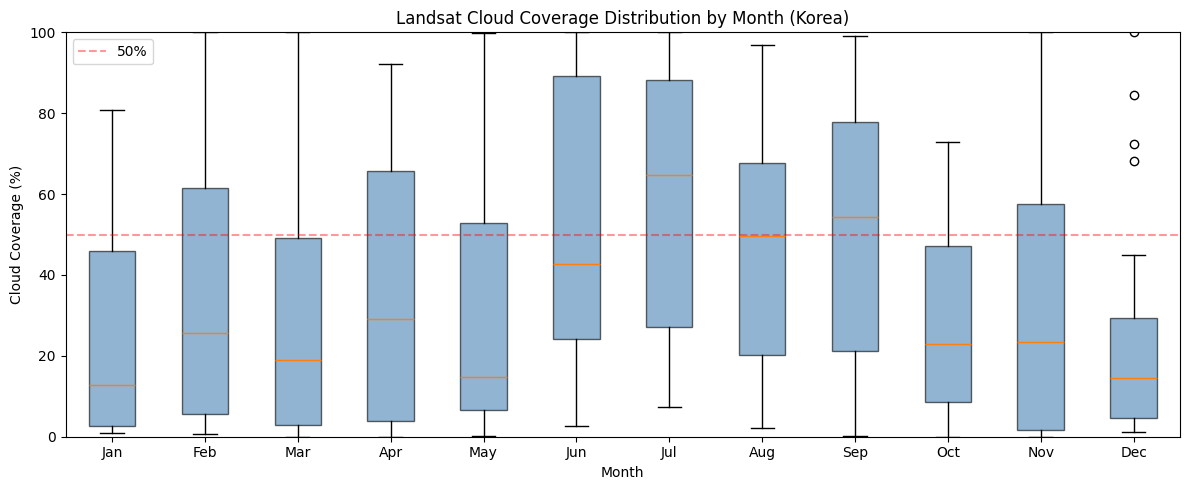

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

months = sorted(cloud_percent_per_month.keys())
data = [cloud_percent_per_month[m] for m in months]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ax.boxplot(data, labels=[month_labels[m-1] for m in months], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))

ax.set_xlabel('Month')
ax.set_ylabel('Cloud Coverage (%)')
ax.set_title('Landsat Cloud Coverage Distribution by Month (Korea)')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.4, label='50%')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Landsat 데이터 처리하기 ───────────────────────

# --- INSPECT ---
landsat_col.size().getInfo()                    # number of images
landsat_col.first().getInfo()                   # metadata of first image

# --- FILTER MORE ---
'''
월 별로 filtering 가능
'''
#landsat_col.filter(ee.Filter.calendarRange(6, 8, 'month')) # summer only

'\n월 별로 filtering 가능\n'

마지막으로 이미지 np array로 바꿔 저장

In [ ]:
# ============================================================
# 12. 12개 도시 패치 추출 및 Drive 저장
# ============================================================
# patch_rois의 모든 도시에 대해 LST 패치를 추출하고
# Drive에 도시별 폴더로 저장
# - 60m 해상도, UTM Zone 52N 기준 256×256 픽셀
# - 구름 픽셀이 30% 이상이면 skip
# ============================================================

import os

# NaN 대신 사용할 표시 값 (JSON이 NaN을 지원하지 않아서 우회용)
SENTINEL = -9999


# ── 도시 하나에 대해 패치 추출 + 저장하는 함수 ──────
def extract_city(city_name, roi):
    """한 도시의 ROI에 대해 LST 패치를 추출하고 Drive에 저장."""

    # 도시별 저장 폴더 생성
    save_dir = f'{SAVE_BASE}/{city_name}'
    os.makedirs(save_dir, exist_ok=True)

    # 해당 도시 ROI에 맞춰 Landsat 컬렉션 구성
    col = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
           .filterBounds(roi)
           .filterDate(START, END)
           .map(mask_clouds)
           .map(apply_st_scale)
           .select('ST_K'))
#           .filter(ee.Filter.lt('CLOUD_COVER', CLOUD_THRESHOLD))

    n = col.size().getInfo()
    print(f'\n=== {city_name} ({n} images) ===')

    if n == 0:
        print(f'  → 이미지 없음, 건너뜀')
        return

    image_list = col.toList(n)
    saved, skipped, failed = 0, 0, 0

    # 컬렉션 안 모든 이미지 순회
    for i in range(n):
        image = ee.Image(image_list.get(i))
        date = image.date().format('YYYY-MM-dd').getInfo()

        try:
            # 마스킹된 픽셀을 SENTINEL로 채움 (JSON NaN 회피)
            image_filled = image.unmask(SENTINEL)

            # UTM 좌표계로 재투영 후 패치 영역을 픽셀 배열로 가져옴
            patch = (image_filled
                     .reproject(crs='EPSG:32652', scale=60)
                     .sampleRectangle(region=roi, defaultValue=SENTINEL)
                     .getInfo())

            # numpy 배열로 변환, SENTINEL을 NaN으로 복원
            arr = np.array(patch['properties']['ST_K'], dtype=float)
            arr[arr == SENTINEL] = np.nan

            # 구름 픽셀 비율 30% 초과면 skip
            if np.isnan(arr).mean() > (CLOUD_THRESHOLD / 100):
                print(f'  {date}: skipped ({np.isnan(arr).mean():.0%} cloud)')
                skipped += 1
                continue

            # 좌표 변환 오차 보정용으로 256×256 자르기
            arr = arr[:256, :256]

            # Drive에 저장
            np.save(f'{save_dir}/{date}.npy', arr)
            print(f'  {date}: saved {arr.shape}')
            saved += 1

        except Exception as e:
            print(f'  {date}: failed — {e}')
            failed += 1

    # 도시별 요약
    print(f'  → {city_name} 완료: saved={saved}, skipped={skipped}, failed={failed}')


# ── 모든 도시에 대해 실행 ──────────────────────────
for city_name, roi in patch_rois.items():
    extract_city(city_name, roi)

print('\n=== 전체 추출 완료 ===')


=== seoul (309 images) ===
  2013-03-27: saved (256, 256)
  2013-05-20: skipped (100% cloud)
  2013-06-05: skipped (97% cloud)
  2013-09-09: skipped (100% cloud)
  2013-10-11: skipped (100% cloud)
  2013-11-12: skipped (99% cloud)
  2013-11-28: skipped (99% cloud)
  2013-12-14: skipped (96% cloud)
  2013-12-30: skipped (97% cloud)
  2014-01-31: skipped (97% cloud)
  2014-02-16: skipped (100% cloud)
  2014-03-20: skipped (100% cloud)
  2014-04-05: skipped (96% cloud)
  2014-04-21: skipped (97% cloud)
  2014-05-07: skipped (100% cloud)
  2015-03-07: skipped (99% cloud)
  2015-03-23: skipped (99% cloud)
  2015-04-08: skipped (100% cloud)
  2015-04-24: skipped (84% cloud)
  2015-05-10: skipped (93% cloud)
  2016-04-26: skipped (98% cloud)
  2017-04-13: skipped (100% cloud)
  2017-10-22: skipped (100% cloud)
  2017-11-07: skipped (100% cloud)
  2017-12-25: skipped (100% cloud)
  2020-04-21: skipped (100% cloud)
  2020-05-07: skipped (96% cloud)
  2021-04-08: skipped (100% cloud)
  2021-04-

KeyboardInterrupt: 

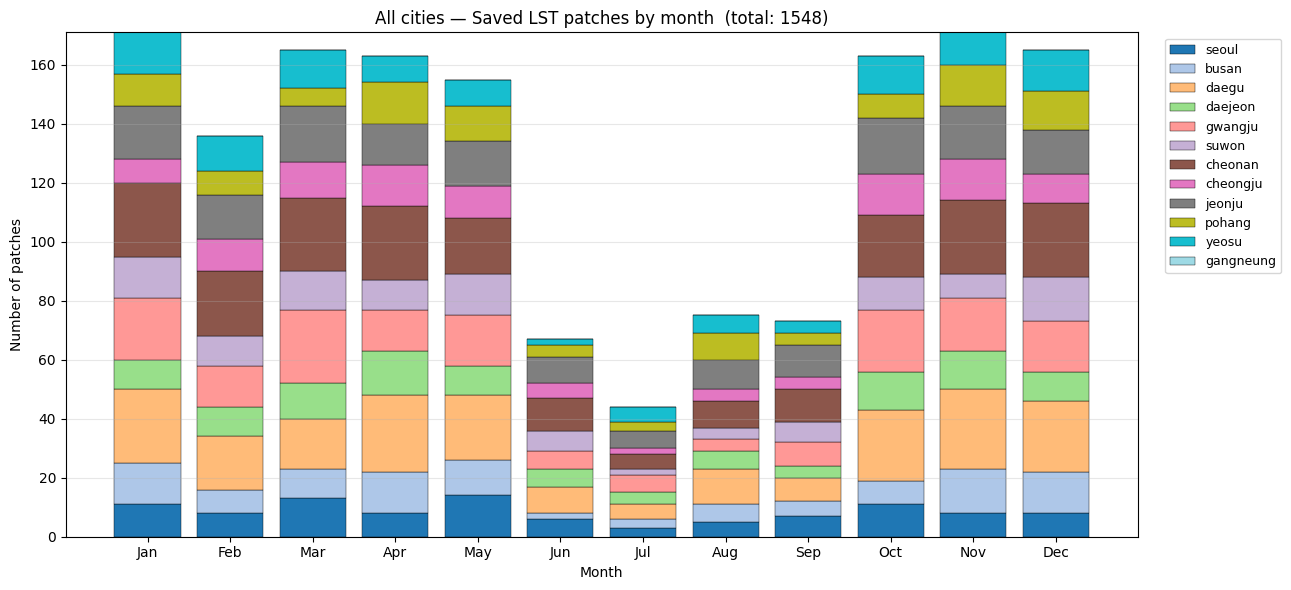

In [ ]:
# ============================================================
# 시각화 1c: 도시별 색깔로 누적
# ============================================================
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime

cities = list(patch_rois.keys())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# 도시별 월별 카운트 행렬
city_counts = {}
for city in cities:
    save_dir = f'{SAVE_BASE}/{city}'
    if not os.path.exists(save_dir):
        city_counts[city] = [0]*12
        continue
    files = [f for f in os.listdir(save_dir) if f.endswith('.npy')]
    months = [datetime.strptime(f.replace('.npy', ''), '%Y-%m-%d').month for f in files]
    city_counts[city] = [months.count(m) for m in range(1, 13)]

# 누적 그리기
fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(12)
colors = plt.cm.tab20(np.linspace(0, 1, len(cities)))

for city, color in zip(cities, colors):
    counts = city_counts[city]
    ax.bar(month_labels, counts, bottom=bottom, color=color, label=city, edgecolor='black', linewidth=0.3)
    bottom += np.array(counts)

ax.set_xlabel('Month')
ax.set_ylabel('Number of patches')
ax.set_title(f'All cities — Saved LST patches by month  (total: {int(bottom.sum())})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

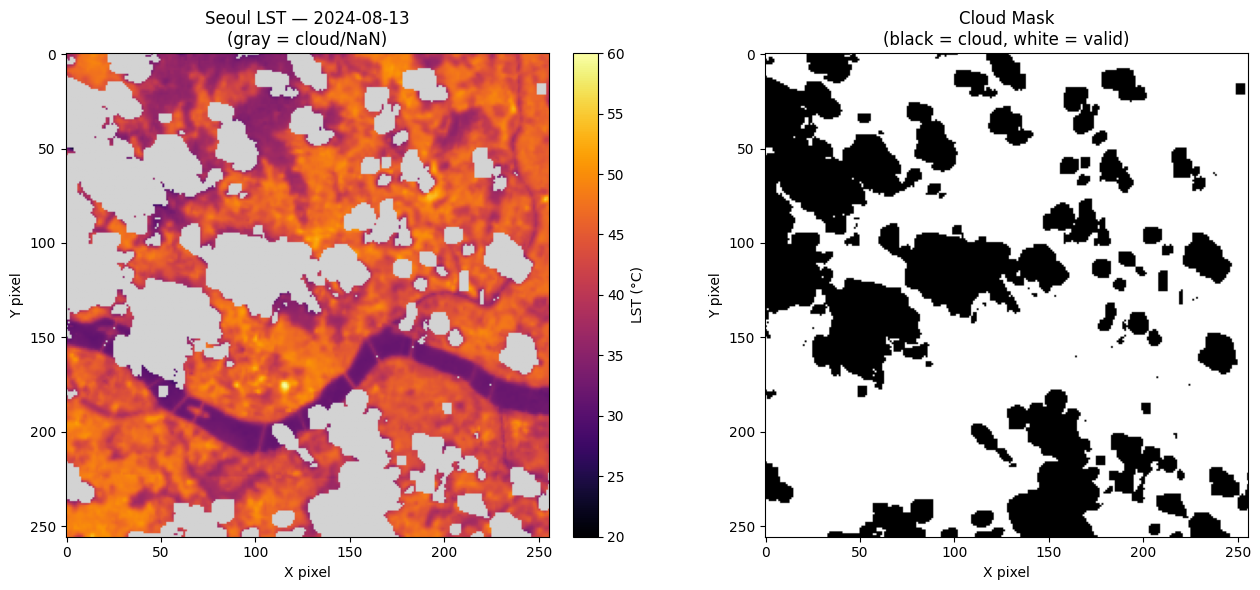


seoul 2024-08-13 LST 통계 (°C)
  최저:   24.0
  중앙값: 43.7
  최고:   60.4
  NaN 비율: 30.1%


In [ ]:
# ============================================================
# 시각화 2: 특정 날짜 LST 패치
# ============================================================
CITY = 'seoul'
DATE = '2024-08-13'

arr = np.load(f'{SAVE_BASE}/{CITY}/{DATE}.npy')
arr_celsius = arr - 273.15

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cmap = plt.cm.inferno.copy()
cmap.set_bad('lightgray')

im1 = axes[0].imshow(arr_celsius, cmap=cmap, vmin=20, vmax=60)
axes[0].set_title(f'{CITY.capitalize()} LST — {DATE}\n(gray = cloud/NaN)')
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[0], label='LST (°C)', fraction=0.046, pad=0.04)

nan_mask = np.isnan(arr).astype(float)
axes[1].imshow(nan_mask, cmap='gray_r', vmin=0, vmax=1)
axes[1].set_title('Cloud Mask\n(black = cloud, white = valid)')
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')

plt.tight_layout()
plt.show()

valid = arr_celsius[~np.isnan(arr_celsius)]
print(f'\n{CITY} {DATE} LST 통계 (°C)')
print(f'  최저:   {valid.min():.1f}')
print(f'  중앙값: {np.median(valid):.1f}')
print(f'  최고:   {valid.max():.1f}')
print(f'  NaN 비율: {np.isnan(arr).mean():.1%}')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
